In [99]:
%reset -f

In [1]:
import numpy as np
import pandas as pd
import os
import matplotlib.pyplot as plt
from matplotlib import cm
from matplotlib.colors import Normalize 
import matplotlib.style as style 
style.use('seaborn-colorblind')

%matplotlib inline
%config InlineBackend.figure_format = 'retina'

from scipy import stats
from scipy.interpolate import interpn

import xgboost as xgb

import warnings
warnings.filterwarnings('ignore')

root_dir = '/Users/weiweizhan/Desktop/Weiwei_Zhan/Projects/WUE'
os.chdir(root_dir)


import matplotlib
pd.set_option('mode.chained_assignment', None)
plt.rcParams["legend.frameon"] = False
plt.rcParams['savefig.dpi'] = 400
plt.rcParams['font.size'] = 11

/var/folders/17/m2hbh37n5h71bqc9bp3sk5h00000gn/T/ipykernel_6755/8515748.py:8: MatplotlibDeprecationWarning: The seaborn styles shipped by Matplotlib are deprecated since 3.6, as they no longer correspond to the styles shipped by seaborn. However, they will remain available as 'seaborn-v0_8-<style>'. Alternatively, directly use the seaborn API instead.
  style.use('seaborn-colorblind')


# site example for the differencing method

## import data

In [2]:
sitecode    = 'US-Ho1'
target      = 'iWUE'
CO2_var     = 'CAMS_CO2'
predictors  = ['Tair','RH','SW','LAI','WS','SWC']

In [3]:
# full record of the site
data_full = pd.read_csv(f'./Data/site_example/{sitecode}.csv',index_col=0,parse_dates=True)

# relevant variables
var_s  = [target,'Tair','RH','VPD','SW','LAI','WS','SWC','CAMS_CO2']

# ---------- select GS remove NAN -------------
# data for model training: 
# growing season + remove nan values in predictors & predictand (note we allow nan values exist in SWC)
df_model = data_full[(data_full['flag_GS_cont_DT']==1)]
df_model = df_model[var_s].astype('float32')

noSWC_vars    = [item for item in var_s if item not in ['SWC']] 
nonan_y_index = df_model[noSWC_vars].dropna().index.tolist()
df_model      = df_model[df_model.index.isin(nonan_y_index)]

## load model

In [4]:
# ---------------- load models ----------------
trained_model_dir = './Data/site_example/'

# model
## w/o CO2
model_path_noCO2 = os.path.join(trained_model_dir,target+'_'+sitecode+'_noCO2.json')
model_noCO2 = xgb.XGBRegressor()
model_noCO2.load_model(model_path_noCO2)

## with CO2
model_path_CO2 = os.path.join(trained_model_dir,target+'_'+sitecode+'_CO2.json')
model_CO2 = xgb.XGBRegressor()
model_CO2.load_model(model_path_CO2)

## apply the differencing method

In [5]:
# data for differencing analysis:
# growing season + remove nan values in predictors (allow nan in SWC and predictand)
noSWC_vars  = [item for item in (predictors+[CO2_var]) if item not in ['SWC']] 
noNAN_index = data_full[noSWC_vars].dropna().index.tolist()

GS_mask     = (data_full['flag_GS_cont_DT']==1)
mask        = GS_mask & (data_full.index.isin(noNAN_index))
data_full   = data_full[mask]


#----------- calculate the difference between f(climate,LAI,CO2) and f(climate,LAI) ------------
y_obs     = df_model[target].values.flatten()

# XGBoost(climate,LAI,CO2) - XGBoost(climate,CO2)
df        = data_full.copy() 
    
# model estimates (with CO2 as input)
X1        = df[predictors+[CO2_var]]
y_hat1    = model_CO2.predict(X1)

# model estimates (w/o CO2 as input)
X2        = df[predictors]
y_hat2    = model_noCO2.predict(X2)

# difference
epsilon1  = y_hat1 - y_hat2

Below we define the key functions used to implement the differencing method, as well as to compute the $\beta$ factor and the SNR metric.

In [6]:
def differencing_method_analysis_plot(x, y, s, cmap='magma', xy=(.5,.05), ax=None, fig=None, 
                                      sort=True, bins=20, fontsize=11,annotate=True, diag_line=True,
                                      reg_line=False, **kwargs):
    '''
    This function is used to implement the differencing method, i.e., to plot the scatter of (y2 - y1) vs CO2,
    and fit the regression line to obtain the beta & SNR values
    '''
    
    if ax is None :
        fig , ax = plt.subplots()
        
    data , x_e, y_e = np.histogram2d( x, y, bins = bins, density = True )
    z = interpn( ( 0.5*(x_e[1:] + x_e[:-1]) , 0.5*(y_e[1:]+y_e[:-1]) ) , data , 
                np.vstack([x,y]).T , method = "splinef2d", bounds_error = False)

    # To be sure to plot all data
    z[np.where(np.isnan(z))] = 0.0

    # Sort the points by density, so that the densest points are plotted last
    if sort :
        idx = z.argsort()
        x, y, z = x[idx], y[idx], z[idx]

    im = ax.scatter(x, y, c=z, s=s, cmap=cmap, **kwargs )
    
    # add the colorbar
    norm = Normalize(vmin = np.min(z), vmax = np.max(z))
    cbar = fig.colorbar(cm.ScalarMappable(norm = norm,cmap=cmap), ax=ax)
    cbar.ax.set_ylabel('Density')
    cbar.formatter.set_powerlimits((0, 0))
    cbar.ax.yaxis.set_offset_position('left')                         
    cbar.update_ticks()
    
    # add the values of metrics
    # regression & regression line
    slope, intercept= fit_regression(x,y)
                                        
    # add the diagonal line
    min_x, max_x = ax.get_xlim()
    min_y, max_y = ax.get_ylim()

    max_value = max(max_x,max_y)
    min_value = min(min_x,min_y)
        
    line = np.linspace(min_value, max_value, 100)
    if diag_line:
        ax.plot(line, line,'--',color='black')
    
    x_range = np.linspace(min_x, max_x, 100)
    y_pre = x_range*slope+intercept
    if reg_line:
        ax.plot(x_range, y_pre,color='black')

    return ax,slope,intercept,cbar,im


from scipy.optimize import minimize
def loss(params, X, y):
    w, b = params
    y_pred = w * X + b
    mse_loss = np.mean((y - y_pred)**2)
    mae_loss = np.mean(np.abs(y-y_pred))
    return mae_loss

def fit_regression(X,y):
    # Initial guess for parameters
    initial_params = np.array([0.0, 0.0])
    
    # Perform optimization using L1 norm
    result = minimize(loss, initial_params, args=(X, y))
    
    # Extract optimized parameters
    optimal_params = result.x
    slope, intercept = optimal_params
    
    return slope,intercept

In [7]:
def calulate_SNR(y,data,slope,x_var='CO2'):
    
    delta_x   = data[x_var].max() - data[x_var].min()
    y_detrend = detrend_y(y)
    y_std     = y_detrend.std()
    
    SNR = slope*delta_x/y_std
    return SNR, y_std

def detrend_y(y):
    x = np.arange(len(y))
    slope, intercept, r_value, p_value, std_err = stats.linregress(x, y)
    y_pre     = x*slope + intercept
    y_detrend = y - y_pre
    
    return y_detrend

def calculate_beta_factor(data_full,CO2_var,target,slope):

    CO2_mean = data_full[CO2_var].mean()
    y_mean   = data_full[target].mean()
    
    CO2_e = np.nanquantile(data_full[CO2_var],0.9)
    CO2_a = np.nanquantile(data_full[CO2_var],0.1)
    
    y_e  = y_mean + slope*(CO2_e - CO2_mean)
    y_a  = y_mean + slope*(CO2_a - CO2_mean)
    
    beta = np.log(y_e/y_a)/np.log(CO2_e/CO2_a)

    return beta

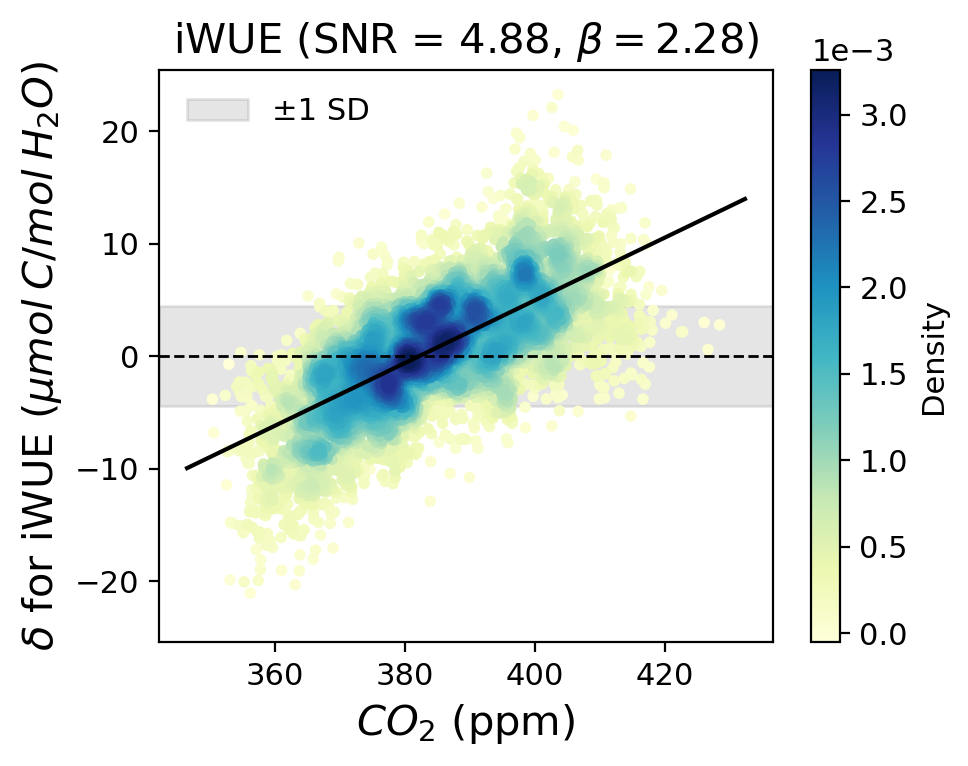

In [8]:
#------------- plot --------------
fig, ax = plt.subplots(figsize=(5,4))

nonan_idx  = (~df[CO2_var].isna()).values
_,slope,intercept,cbar1,im1 = differencing_method_analysis_plot(df[CO2_var][nonan_idx],epsilon1[nonan_idx],s=10,
                                                                bins=[30,30],sort=True,
                                                                cmap='YlGnBu',ax=ax,fig=fig,
                                                                diag_line=False,reg_line=True)
## calculate the signal/noise metric
SNR,std = calulate_SNR(epsilon1,df,slope,x_var=CO2_var)

## calculate the beta factor
beta = calculate_beta_factor(data_full,CO2_var,target,slope)

# set labels & titles
yabs_max = abs(max(ax.get_ylim(), key=abs))
ax.set_ylim(ymin=-yabs_max, ymax=yabs_max)

subtitle = 'SNR = ${%.2f}$'%(SNR)+', '+r'$\beta = {%.2f}$'%(beta)
unit = '$\mu mol\:C/mol\:H_{2}O$'

ax.set_ylabel(f'$\delta$ for {target} ({unit})',fontsize=15) 
ax.set_xlabel('$CO_2$ (ppm)',fontsize=15)
ax.set_title(f'{target} ({subtitle})',fontsize=15)

ax.axhline(0, color='black',linestyle='--' ,linewidth=1)
ax.axhspan(-std, std, color='gray', alpha=0.2, label='±1 SD',zorder=0)
ax.legend()


plt.tight_layout()